In [2]:
import pandas as pd
import requests
from io import StringIO

In [5]:
df = pd.read_csv(StringIO(requests.get('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day42-outlier-removal-using-zscore/placement.csv').text))
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [7]:
df.isnull().sum()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

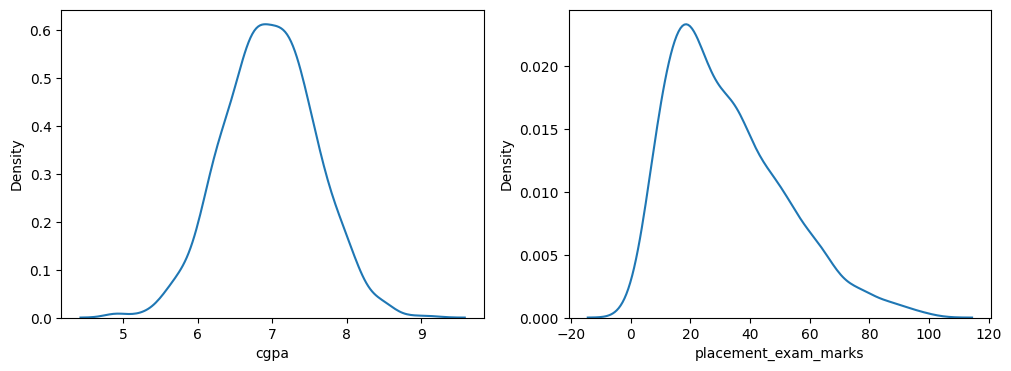

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
sns.kdeplot(df['cgpa'], label='cgpa', ax = ax1)
ax2 = fig.add_subplot(122)
sns.kdeplot(df['placement_exam_marks'], label='cgpa', ax = ax2)
plt.show()

## trim approach1

In [42]:
import numpy as np
lower = df['cgpa'].mean() - 3 * df['cgpa'].std()
upper = df['cgpa'].mean() + 3 * df['cgpa'].std()
outliers = df[(df['cgpa'] < np.round(lower, 2)) | (df['cgpa'] > np.round(upper, 2))]
outliers
new_df = df[(df['cgpa'] >= np.round(lower, 2)) & (df['cgpa'] <= np.round(upper, 2))]
new_df.shape


(995, 3)

## trim approach2

In [46]:
df['zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()
new_df = df[(df['zscore'] >= -3) & (df['zscore'] <= 3)]
new_df.shape

(995, 4)

## cap approach

In [55]:
df['cgpa'] = np.where(df['cgpa'] > upper, upper, (np.where(df['cgpa'] < lower, lower, df['cgpa'])))
df.describe()

,cgpa,placement_exam_marks,placed,zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00
